$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 4.4

## 理论

接下来分析表 2.1 中的有理二次（RQ）相关函数，该函数也被称作逆二次核或柯西核：

$$
R(\boldsymbol{\Delta}) = \frac{1}{1+\frac{\|\boldsymbol{\Delta}\|^2}{\theta^2}}
\tag{4.17}
$$

于是式 (4.14) 中的目标函数可写为：

$$
\begin{align*}
\|\boldsymbol{R}-\boldsymbol{I}_n\|_\alpha^\alpha&=\sum_{i=1}^n\sum_{j\neq i}\frac{1}{\left({1+\frac{\|\boldsymbol{x}_i-\boldsymbol{x}_j\|^2}{\theta^2}}\right)^\alpha}\\
&\le\theta^{2\alpha}\sum_{i=1}^n\sum_{j\neq i}\frac{1}{\|\boldsymbol{x}_i-\boldsymbol{x}_j\|^{2\alpha}}
\end{align*}
$$

该上界中的第二项为总倒数距离（TRD），该指标的特点是不含参数 $\theta$，可作为式 (4.16) 的替代评判准则。不难看出，当 $\alpha$ 取值很大时：

$$
\begin{align*}
\min_D TRD(D)&=\min_D\sum_{i=1}^n\sum_{j\neq i}\frac{1}{\|\boldsymbol{x}_i-\boldsymbol{x}_j\|^{2\alpha}}
\tag{4.18}\\
&\approx\min_D\frac{I}{\min_{i\neq j}\|\boldsymbol{x}_i-\boldsymbol{x}_j\|^{2\alpha}}\\
&\equiv\max_{D}\frac{\min_{i\neq j}\|\boldsymbol{x}_i-\boldsymbol{x}_j\|}{I^{1/(2\alpha)}}
\end{align*}
$$

式中 $I$ 代表设计索引，代表距离等于全局最小距离的点对数。因此当 $\alpha$ 足够大时，最小化总倒数距离 $TRD(D)$ 既能最大化样本点间的最小距离，还可实现设计索引最小化。由此可见，相较于式 (4.16) 中的极大极小准则，总倒数距离准则的表现更优。而式 (4.16) 的优势在于其目标函数的计算复杂度为 $\mathcal{O}(n\log n)$，总倒数距离 $TRD(D)$ 的计算复杂度则为 $\mathcal{O}(n^2)$。

与极小极大设计的情形类似，在一维问题中求解极大极小设计十分简便。含 $n$ 个试验点的极大极小设计表达式为：

$$
D=\left\{\frac{i-1}{n-1}\right\}_{i=1}^{n}
\tag{4.19}
$$

当维度 $p \ge 2$ 时，除非选取 $n=2p$ 这类特殊的样本量取值，否则求解极大极小设计将会变得十分困难。优化轨迹距离准则 $TRD(D)$ 的难度更低，其梯度表达式为：

$$
\begin{align*}
\frac{\partial TRD}{\partial x_k} &= 2\sum_{j\ne k} \frac{\partial}{\partial \boldsymbol{x}_{k}} \left(\|\boldsymbol{x}_{j}-\boldsymbol{x}_{k}\|^{-2\alpha}\right) \\
&= \sum_{j\ne k} -4\alpha \|\boldsymbol{x}_{j}-\boldsymbol{x}_{k}\|^{-2\alpha-1} \frac{\partial \|\boldsymbol{x}_{j}-\boldsymbol{x}_{k}\|}{\partial \boldsymbol{x}_{k}} \\
&= \sum_{j\ne k} -4\alpha \|\boldsymbol{x}_{j}-\boldsymbol{x}_{k}\|^{-2\alpha-2} (\boldsymbol{x}_{j}-\boldsymbol{x}_{k})
\end{align*}
$$

可基于该梯度开展梯度类优化运算。但由于 $TRD(D)$ 属于多峰函数，该优化过程极易收敛至局部最优解。因此，需要设置多组随机初始值，以此搜寻全局最优解。若要求解式 (4.16) 中的极大极小设计，可采用无导数全局优化算法；但当 $n$ 与 $p$ 数值较大时，该算法运算速度较慢。

采用 SFDesign 构造得到的样本量 $n=7$、维度 $p=2$ 的极大极小设计如图 4.4 所示，其分离距离 $\psi(D^*)=0.26795$。以各个设计点为圆心、$\psi(D^*)$ 为半径绘制圆形。极大极小设计能够最大化可布置在每个设计点周围、互不重叠的相同球体半径。

## 实践

创建画布宽 10 英寸、高 10 英寸。令 p=2，n=7，设置种子为 1。导入 SFDesign 包，调用 maximinLHD() 函数生成 n 个点，p 维的初始极大极小拉丁超立方设计，再在初始设计基础上做优化，其中启用模拟退火算法全局优化，自动挑选最优初始布局，取返回列表中的 design 列正是最终的极大极小设计点横纵坐标 D。依据公式

$$
\psi(D) := \frac{1}{2}\min_{i\neq j}\|\boldsymbol{x}_i-\boldsymbol{x}_j\|
$$

计算 $\psi(D)$，令其为 r 并打印。绘制 D 的散点图，其中 x 轴标注为 expression(x[1])，y 轴标注为 expression(x[2])，x、y 轴范围均为 c(0,1)，点形状为 16，点颜色为 blue，点大小为 3，标题为 “极大极小设计”，大小为 3，轴标签大小为 2，轴大小为 2，纵横比为 1。导入 plotrix 包，调用 draw.circle() 函数绘制圆形，其中圆心坐标分别为 D 的两列（共两列），半径为 r，线宽为 2。

r: 0.267948 


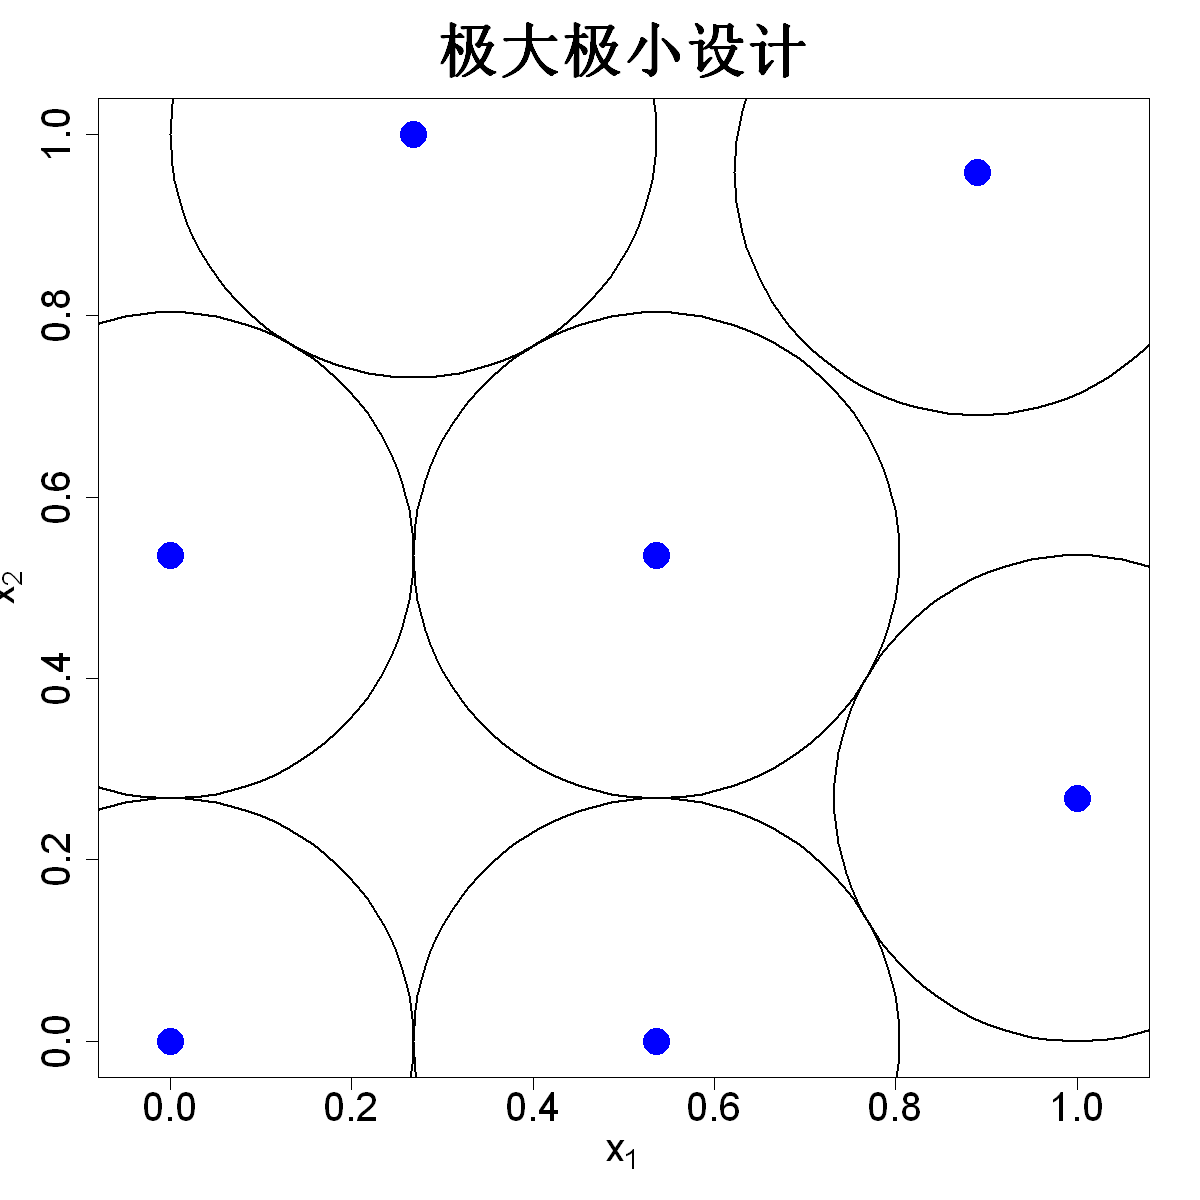

In [2]:
options(repr.plot.width=10,repr.plot.height=10)
p=2;n=7
set.seed(1)
library(SFDesign)
D=maximin.optim(maximinLHD(n,p)$design,sa=TRUE,find.best.ini=TRUE)$design
r=min(dist(D))/2
cat("r:",r,"\n")
plot(D,xlab=expression(x[1]),ylab=expression(x[2]),xlim=c(0,1),ylim=c(0,1),pch=16,col="blue",cex=3,cex.main=3,cex.lab=2,cex.axis=2,main="极大极小设计",asp=1)
library(plotrix)
for(i in 1:n)draw.circle(D[i,1],D[i,2],radius=r,lwd=2)

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$